<a href="https://colab.research.google.com/github/mmallare/ECGR4106/blob/main/ecgr4106_homework3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import and token setup
import sys
import subprocess

try:
    import nltk
except ImportError:
    print("NLTK library not found. Installing it now...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "nltk"])
    import nltk

import random
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch
import torch.nn as nn
import torch.nn.functional as F
from nltk.translate.bleu_score import SmoothingFunction, sentence_bleu
from torch.utils.data import DataLoader, Dataset

PAD_token = 0
SOS_token = 1
EOS_token = 2
UNK_token = 3  # words seen in validation but never seen during training

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')



DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/vast_english_french.txt'

with open(DATA_PATH, 'r') as file:
  content = file.read()
  #print(content)

N_EPOCHS = 50
HIDDEN_SIZE = 128
LEARNING_RATE = 0.001
TEACHER_FORCING_RATIO = 0.5
N_QUALITATIVE_EXAMPLES = 5
MAX_GEN_LENGTH = 20
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def normalize_string(s: str) -> str:
    """Lowercase, separate punctuation into its own token, keep accented
    French letters (we do NOT strip accents - that would corrupt French)."""
    s = s.lower().strip()
    s = re.sub(r"([.!?,])", r" \1 ", s)
    s = re.sub(r"[^a-z\u00e0-\u00f6\u00f8-\u00ff0-9'\-.,!?\s]", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def load_pairs(filepath: str, reverse: bool = False):
    """Loads tab-separated 'English\tFrench' pairs (falls back to commas).
    reverse=True swaps to (french, english)."""
    pairs = []
    with open(filepath, encoding="utf-8") as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line:
                continue
            parts = line.split("\t")
            if len(parts) < 2:
                parts = line.split(",")
            if len(parts) < 2:
                continue
            eng, fr = normalize_string(parts[0]), normalize_string(parts[1])
            if not eng or not fr:
                continue
            pairs.append((fr, eng) if reverse else (eng, fr))
    return pairs

def split_pairs(pairs, val_fraction=0.2, seed=42):
    """Fixed-seed 80/20 split -> identical split across all three problems."""
    rng = random.Random(seed)
    shuffled = pairs[:]
    rng.shuffle(shuffled)
    n_val = int(len(shuffled) * val_fraction)
    return shuffled[n_val:], shuffled[:n_val]  # train, val

def compute_max_length(pairs):
    longest = 0
    for a, b in pairs:
        longest = max(longest, len(a.split(" ")), len(b.split(" ")))
    return longest + 1

# Vocabulary
class Vocabulary:
    def __init__(self):
        self.word2index = {"<PAD>": PAD_token, "<SOS>": SOS_token,
                            "<EOS>": EOS_token, "<UNK>": UNK_token}
        self.index2word = {v: k for k, v in self.word2index.items()}
        self.word_count = {}
        self.n_words = 4

    def add_sentence(self, sentence):
        for word in sentence.split(" "):
            if word:
                self.add_word(word)

    def add_word(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.index2word[self.n_words] = word
            self.word_count[word] = 1
            self.n_words += 1
        else:
            self.word_count[word] += 1

    def indices_from_sentence(self, sentence):
        return [self.word2index.get(w, UNK_token) for w in sentence.split(" ") if w]


def sentence_to_tensor(vocab, sentence):
    indices = vocab.indices_from_sentence(sentence) + [EOS_token]
    return torch.tensor(indices, dtype=torch.long, device=device).view(-1, 1)


def indices_to_words(vocab, indices):
    return [vocab.index2word.get(i, "<UNK>") for i in indices]


class TranslationPairDataset(Dataset):
    def __init__(self, pairs, src_vocab, tgt_vocab):
        self.pairs, self.src_vocab, self.tgt_vocab = pairs, src_vocab, tgt_vocab

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src_sentence, tgt_sentence = self.pairs[idx]
        return (sentence_to_tensor(self.src_vocab, src_sentence),
                sentence_to_tensor(self.tgt_vocab, tgt_sentence))


def make_dataloader(pairs, src_vocab, tgt_vocab, shuffle):
    return DataLoader(TranslationPairDataset(pairs, src_vocab, tgt_vocab),
                       batch_size=1, shuffle=shuffle)

In [ ]:
# Models (GRU)
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)

    def forward(self, input_token, hidden):
        embedded = self.embedding(input_token).view(1, 1, -1)
        return self.gru(embedded, hidden)

    def init_hidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)


class DecoderRNN(nn.Module):
    #Problem 1: No attention

    def __init__(self, hidden_size, output_size, dropout_p=0.3):
        super().__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.dropout = nn.Dropout(dropout_p)
        self.gru = nn.GRU(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, input_token, hidden):
        embedded = F.relu(self.dropout(self.embedding(input_token).view(1, 1, -1)))
        output, hidden = self.gru(embedded, hidden)
        return F.log_softmax(self.out(output[0]), dim=1), hidden


class AttnDecoderRNN(nn.Module):
    # Problem 2: Bahdanau-style

    def __init__(self, hidden_size, output_size, max_length, dropout_p=0.1):
        super().__init__()
        self.hidden_size = hidden_size
        self.max_length = max_length
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.dropout = nn.Dropout(dropout_p)
        self.attn = nn.Linear(hidden_size * 2, max_length)
        self.attn_combine = nn.Linear(hidden_size * 2, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, input_token, hidden, encoder_outputs):
        embedded = self.dropout(self.embedding(input_token).view(1, 1, -1))
        attn_weights = F.softmax(self.attn(torch.cat((embedded[0], hidden[0]), 1)), dim=1)
        attn_applied = torch.bmm(attn_weights.unsqueeze(0), encoder_outputs.unsqueeze(0))
        output = torch.cat((embedded[0], attn_applied[0]), 1)
        output = F.relu(self.attn_combine(output).unsqueeze(0))
        output, hidden = self.gru(output, hidden)
        return F.log_softmax(self.out(output[0]), dim=1), hidden, attn_weights

    def init_hidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)


# Train / validation-loss
def compute_loss(input_tensor, target_tensor, encoder, decoder, criterion,
                  use_attention, max_length, teacher_forcing_ratio,
                  encoder_optimizer=None, decoder_optimizer=None, train=False):
    encoder_hidden = encoder.init_hidden()
    if train:
        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

    input_length, target_length = input_tensor.size(0), target_tensor.size(0)
    loss = 0.0

    if use_attention:
        encoder_outputs = torch.zeros(max_length, encoder.hidden_size, device=device)
        for ei in range(input_length):
            encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
            encoder_outputs[ei] = encoder_output[0, 0]
    else:
        encoder_outputs = None
        for ei in range(input_length):
            _, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)

    decoder_input = torch.tensor([[SOS_token]], device=device)
    decoder_hidden = encoder_hidden
    use_tf = random.random() < teacher_forcing_ratio

    for di in range(target_length):
        if use_attention:
            decoder_output, decoder_hidden, _ = decoder(decoder_input, decoder_hidden, encoder_outputs)
        else:
            decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
        loss = loss + criterion(decoder_output, target_tensor[di])
        if use_tf:
            decoder_input = target_tensor[di].detach().view(1, 1)
        else:
            _, topi = decoder_output.topk(1)
            decoder_input = topi.squeeze().detach().view(1, 1)
            if decoder_input.item() == EOS_token:
                break

    if train:
        loss.backward()
        encoder_optimizer.step()
        decoder_optimizer.step()
    return loss.item() / target_length


def run_epoch(dataloader, encoder, decoder, criterion, use_attention, max_length,
              teacher_forcing_ratio, encoder_optimizer=None, decoder_optimizer=None,
              train=True):
    total_loss = 0.0
    for input_tensor, target_tensor in dataloader:
        input_tensor, target_tensor = input_tensor[0].to(device), target_tensor[0].to(device)
        if train:
            loss = compute_loss(input_tensor, target_tensor, encoder, decoder, criterion,
                                 use_attention, max_length, teacher_forcing_ratio,
                                 encoder_optimizer, decoder_optimizer, train=True)
        else:
            with torch.no_grad():
                loss = compute_loss(input_tensor, target_tensor, encoder, decoder, criterion,
                                     use_attention, max_length, teacher_forcing_ratio=1.0, train=False)
        total_loss += loss
    return total_loss / max(len(dataloader), 1)


# Free-running generation (BLEU / exact-match / qualitative demo)
def generate(input_tensor, encoder, decoder, use_attention, max_length, max_gen_length=20):
    with torch.no_grad():
        encoder_hidden = encoder.init_hidden()
        input_length = input_tensor.size(0)
        if use_attention:
            encoder_outputs = torch.zeros(max_length, encoder.hidden_size, device=device)
            for ei in range(input_length):
                encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
                encoder_outputs[ei] = encoder_output[0, 0]
        else:
            encoder_outputs = None
            for ei in range(input_length):
                _, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)

        decoder_input = torch.tensor([[SOS_token]], device=device)
        decoder_hidden = encoder_hidden
        predicted_indices, attn_matrix = [], []

        for _ in range(max_gen_length):
            if use_attention:
                decoder_output, decoder_hidden, attn_weights = decoder(decoder_input, decoder_hidden, encoder_outputs)
                attn_matrix.append(attn_weights.squeeze().cpu().numpy())
            else:
                decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
            _, topi = decoder_output.topk(1)
            idx = topi.item()
            if idx == EOS_token:
                break
            predicted_indices.append(idx)
            decoder_input = topi.squeeze().detach().view(1, 1)
    return predicted_indices, attn_matrix


def evaluate_dataset(pairs, src_vocab, tgt_vocab, encoder, decoder, use_attention,
                      max_length, n_examples=5, max_gen_length=20):
    encoder.eval(); decoder.eval()
    chencherry = SmoothingFunction()
    correct, total_bleu, examples = 0, 0.0, []
    first_attn, first_attn_tokens = None, None

    for i, (src_sentence, tgt_sentence) in enumerate(pairs):
        src_tensor = sentence_to_tensor(src_vocab, src_sentence)
        target_words = tgt_sentence.split(" ")
        pred_indices, attn_matrix = generate(src_tensor, encoder, decoder, use_attention, max_length, max_gen_length)
        pred_words = indices_to_words(tgt_vocab, pred_indices)
        is_match = pred_words == target_words
        correct += int(is_match)
        bleu = sentence_bleu([target_words], pred_words, smoothing_function=chencherry.method1)
        total_bleu += bleu
        if i < n_examples:
            examples.append((src_sentence, tgt_sentence, " ".join(pred_words), is_match, bleu))
        if use_attention and first_attn is None and len(pred_indices) > 0:
            first_attn, first_attn_tokens = attn_matrix, (src_sentence.split(" "), pred_words)

    n = max(len(pairs), 1)
    encoder.train(); decoder.train()
    return {"accuracy": correct / n, "bleu": total_bleu / n, "examples": examples,
            "attn_example": (first_attn, first_attn_tokens) if use_attention else None}


# Plotting
def plot_loss_curves(train_losses, val_losses, title, out_path):
    plt.figure(figsize=(7, 5))
    epochs = list(range(1, len(train_losses) + 1))
    plt.plot(epochs, train_losses, label="Training Loss")
    plt.plot(epochs, val_losses, label="Validation Loss")
    plt.xlabel("Epoch"); plt.ylabel("Cross-Entropy Loss"); plt.title(title)
    plt.legend(); plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"Saved to {out_path}")


def plot_attention(attn_matrix, src_tokens, pred_tokens, title, out_path):
    import numpy as np
    src_len = len(src_tokens) + 1
    matrix = np.array([row[:src_len] for row in attn_matrix])
    fig, ax = plt.subplots(figsize=(max(6, src_len * 0.6), max(4, len(pred_tokens) * 0.5)))
    cax = ax.matshow(matrix, cmap="viridis")
    fig.colorbar(cax)
    ax.set_xticks(range(src_len)); ax.set_xticklabels(src_tokens + ["<EOS>"], rotation=90)
    ax.set_yticks(range(len(pred_tokens))); ax.set_yticklabels(pred_tokens)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    plt.title(title); plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"Saved to {out_path}")

print("Library loaded.")

Library loaded.


Loaded 555 pairs
Train: 444 | Val: 111
MAX_LENGTH = 15
English vocab: 879 | French vocab: 979
Epoch   1/50 | Train Loss: 4.3020 | Val Loss: 5.1848
Epoch   5/50 | Train Loss: 2.8430 | Val Loss: 4.5429
Epoch  10/50 | Train Loss: 1.3405 | Val Loss: 4.6112
Epoch  15/50 | Train Loss: 0.4735 | Val Loss: 4.7596
Epoch  20/50 | Train Loss: 0.1381 | Val Loss: 4.8497
Epoch  25/50 | Train Loss: 0.0636 | Val Loss: 5.0687
Epoch  30/50 | Train Loss: 0.0473 | Val Loss: 5.1899
Epoch  35/50 | Train Loss: 0.0198 | Val Loss: 5.3958
Epoch  40/50 | Train Loss: 0.0594 | Val Loss: 5.4349
Epoch  45/50 | Train Loss: 0.0071 | Val Loss: 5.4214
Epoch  50/50 | Train Loss: 0.0217 | Val Loss: 5.6038


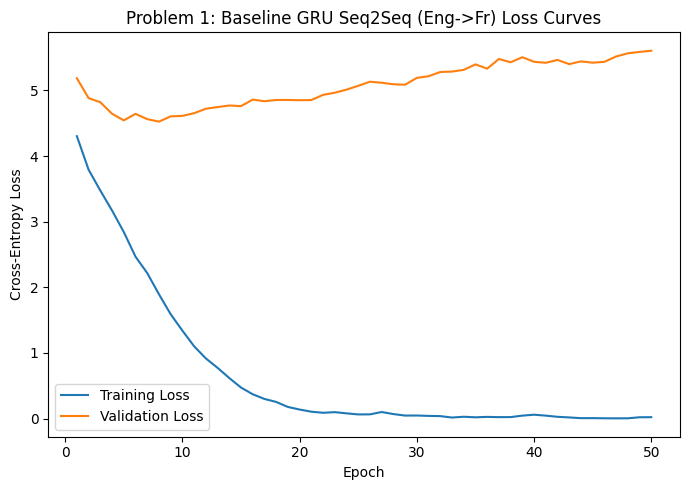

Saved to problem1_loss_curve.png
Exact-Match Accuracy: 0.00%
Average BLEU-4 Score: 0.1126

EN: he teaches world geography to high school classes
  Target: il enseigne la géographie mondiale à des classes de lycée
  Predicted: il enseigne l'histoire à des enfants du collège
  Match: False | BLEU: 0.0647

EN: he plays bass guitar in a professional jazz band
  Target: il joue de la basse dans un groupe de jazz professionnel
  Predicted: il joue de la batterie dans un groupe de jazz
  Match: False | BLEU: 0.5954

EN: the weather forecast predicts heavy snow tomorrow
  Target: les prévisions météo annoncent de fortes chutes de neige demain
  Predicted: le lait biologique doit être gardé de la nuit
  Match: False | BLEU: 0.0215

EN: she loves to wear long flowing cotton skirts
  Target: elle adore porter de longues jupes amples en coton
  Predicted: elle adore porter des jupes longues
  Match: False | BLEU: 0.1392

EN: they listen to the professor with absolute attention
  Target: ils écoute

In [ ]:
# Load + split
pairs1 = load_pairs(DATA_PATH, reverse=False)
print(f"Loaded {len(pairs1)} pairs")
train_pairs1, val_pairs1 = split_pairs(pairs1, val_fraction=0.2, seed=RANDOM_SEED)
print(f"Train: {len(train_pairs1)} | Val: {len(val_pairs1)}")

max_length1 = compute_max_length(pairs1)
print(f"MAX_LENGTH = {max_length1}")

# Vocab (training only)
src_vocab1, tgt_vocab1 = Vocabulary(), Vocabulary()
for eng, fr in train_pairs1:
    src_vocab1.add_sentence(eng)
    tgt_vocab1.add_sentence(fr)
print(f"English vocab: {src_vocab1.n_words} | French vocab: {tgt_vocab1.n_words}")

train_loader1 = make_dataloader(train_pairs1, src_vocab1, tgt_vocab1, shuffle=True)
val_loader1 = make_dataloader(val_pairs1, src_vocab1, tgt_vocab1, shuffle=False)

# Model
encoder1 = EncoderRNN(src_vocab1.n_words, HIDDEN_SIZE).to(device)
decoder1 = DecoderRNN(HIDDEN_SIZE, tgt_vocab1.n_words, dropout_p=0.3).to(device)
enc_opt1 = torch.optim.Adam(encoder1.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
dec_opt1 = torch.optim.Adam(decoder1.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
criterion = nn.NLLLoss()

# Train
train_losses1, val_losses1 = [], []
for epoch in range(1, N_EPOCHS + 1):
    tr_loss = run_epoch(train_loader1, encoder1, decoder1, criterion, False, max_length1,
                         TEACHER_FORCING_RATIO, enc_opt1, dec_opt1, train=True)
    va_loss = run_epoch(val_loader1, encoder1, decoder1, criterion, False, max_length1,
                         teacher_forcing_ratio=1.0, train=False)
    train_losses1.append(tr_loss); val_losses1.append(va_loss)
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{N_EPOCHS} | Train Loss: {tr_loss:.4f} | Val Loss: {va_loss:.4f}")

plot_loss_curves(train_losses1, val_losses1,
                  "Problem 1: Baseline GRU Seq2Seq (Eng->Fr) Loss Curves",
                  "problem1_loss_curve.png")

# Evaluation
problem1_results = evaluate_dataset(val_pairs1, src_vocab1, tgt_vocab1, encoder1, decoder1,
                                     use_attention=False, max_length=max_length1,
                                     n_examples=N_QUALITATIVE_EXAMPLES, max_gen_length=MAX_GEN_LENGTH)
problem1_results["final_val_loss"] = val_losses1[-1]

print(f"Exact-Match Accuracy: {problem1_results['accuracy']*100:.2f}%")
print(f"Average BLEU-4 Score: {problem1_results['bleu']:.4f}\n")
for src, tgt, pred, match, bleu in problem1_results["examples"]:
    print(f"EN: {src}\n  Target: {tgt}\n  Predicted: {pred}\n  Match: {match} | BLEU: {bleu:.4f}\n")

Problem 2

Epoch   1/50 | Train Loss: 4.2063 | Val Loss: 5.1098
Epoch   5/50 | Train Loss: 2.6055 | Val Loss: 4.4136
Epoch  10/50 | Train Loss: 0.9536 | Val Loss: 4.4698
Epoch  15/50 | Train Loss: 0.2516 | Val Loss: 4.5878
Epoch  20/50 | Train Loss: 0.1072 | Val Loss: 4.7010
Epoch  25/50 | Train Loss: 0.0771 | Val Loss: 4.7661
Epoch  30/50 | Train Loss: 0.0266 | Val Loss: 4.8382
Epoch  35/50 | Train Loss: 0.0209 | Val Loss: 4.8898
Epoch  40/50 | Train Loss: 0.0394 | Val Loss: 5.0245
Epoch  45/50 | Train Loss: 0.0347 | Val Loss: 5.2207
Epoch  50/50 | Train Loss: 0.0766 | Val Loss: 5.1172


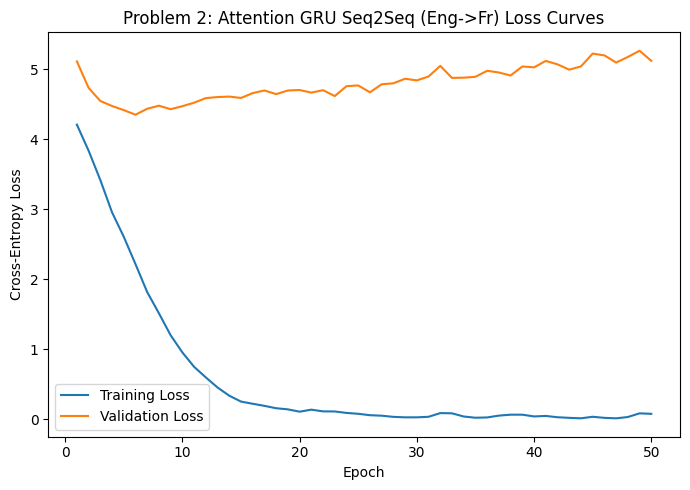

Saved to problem2_loss_curve.png
Exact-Match Accuracy: 1.80%
Average BLEU-4 Score: 0.1352

EN: he teaches world geography to high school classes
  Target: il enseigne la géographie mondiale à des classes de lycée
  Predicted: il enseigne des aux de enfants
  Match: False | BLEU: 0.0527

EN: he plays bass guitar in a professional jazz band
  Target: il joue de la basse dans un groupe de jazz professionnel
  Predicted: il joue de la basse dans un groupe de jazz
  Match: False | BLEU: 0.9048

EN: the weather forecast predicts heavy snow tomorrow
  Target: les prévisions météo annoncent de fortes chutes de neige demain
  Predicted: le bébé sent leurs idées de traverser
  Match: False | BLEU: 0.0215

EN: she loves to wear long flowing cotton skirts
  Target: elle adore porter de longues jupes amples en coton
  Predicted: elle adore porter des jupes historiques de l'environnement
  Match: False | BLEU: 0.1378

EN: they listen to the professor with absolute attention
  Target: ils écoutent le

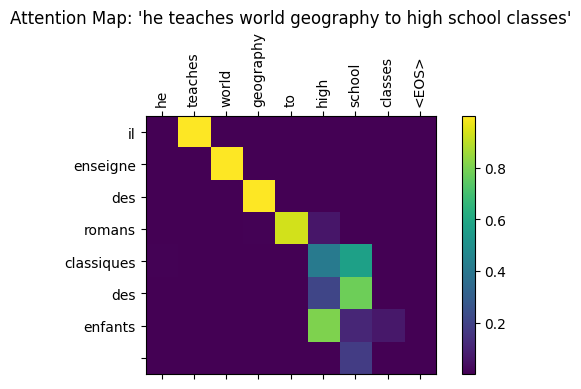

Saved to problem2_attention_map_1.png


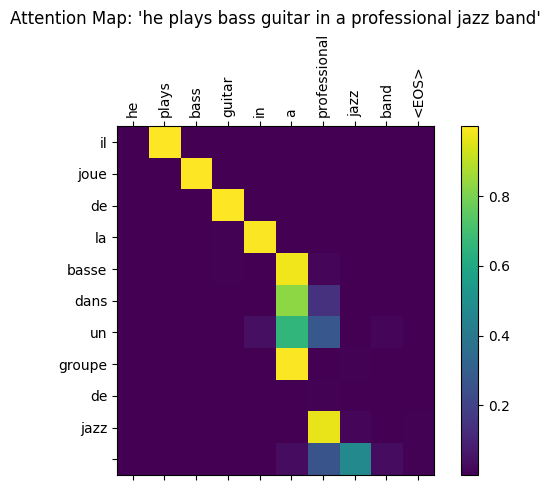

Saved to problem2_attention_map_2.png


In [ ]:
max_length2 = max_length1
encoder2 = EncoderRNN(src_vocab1.n_words, HIDDEN_SIZE).to(device)
decoder2 = AttnDecoderRNN(HIDDEN_SIZE, tgt_vocab1.n_words, max_length=max_length2, dropout_p = 0.3).to(device)
enc_opt2 = torch.optim.Adam(encoder2.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
dec_opt2 = torch.optim.Adam(decoder2.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

train_losses2, val_losses2 = [], []
for epoch in range(1, N_EPOCHS + 1):
    tr_loss = run_epoch(train_loader1, encoder2, decoder2, criterion, True, max_length2,
                         TEACHER_FORCING_RATIO, enc_opt2, dec_opt2, train=True)
    va_loss = run_epoch(val_loader1, encoder2, decoder2, criterion, True, max_length2,
                         teacher_forcing_ratio=1.0, train=False)
    train_losses2.append(tr_loss); val_losses2.append(va_loss)
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{N_EPOCHS} | Train Loss: {tr_loss:.4f} | Val Loss: {va_loss:.4f}")

plot_loss_curves(train_losses2, val_losses2,
                  "Problem 2: Attention GRU Seq2Seq (Eng->Fr) Loss Curves",
                  "problem2_loss_curve.png")
problem2_results = evaluate_dataset(val_pairs1, src_vocab1, tgt_vocab1, encoder2, decoder2,
                                     use_attention=True, max_length=max_length2,
                                     n_examples=N_QUALITATIVE_EXAMPLES, max_gen_length=MAX_GEN_LENGTH)
problem2_results["final_val_loss"] = val_losses2[-1]

print(f"Exact-Match Accuracy: {problem2_results['accuracy']*100:.2f}%")
print(f"Average BLEU-4 Score: {problem2_results['bleu']:.4f}\n")
for src, tgt, pred, match, bleu in problem2_results["examples"]:
    print(f"EN: {src}\n  Target: {tgt}\n  Predicted: {pred}\n  Match: {match} | BLEU: {bleu:.4f}\n")

print("\nComparison vs. Problem 1:")
print(f"  Accuracy: {problem1_results['accuracy']*100:.2f}% -> {problem2_results['accuracy']*100:.2f}%")
print(f"  BLEU-4:   {problem1_results['bleu']:.4f} -> {problem2_results['bleu']:.4f}")

# Attention map visualizations
n_maps = 0
for src_sentence, tgt_sentence in val_pairs1:
    if n_maps >= 2:
        break
    src_tensor = sentence_to_tensor(src_vocab1, src_sentence)
    pred_indices, attn_matrix = generate(src_tensor, encoder2, decoder2, True, max_length2, MAX_GEN_LENGTH)
    if len(pred_indices) == 0:
        continue
    pred_words = indices_to_words(tgt_vocab1, pred_indices)
    n_maps += 1
    plot_attention(attn_matrix, src_sentence.split(" "), pred_words,
                    f"Attention Map: '{src_sentence}'", f"problem2_attention_map_{n_maps}.png")

Problem 3: French to English

Train: 444 | Val: 111 | MAX_LENGTH: 15
French vocab: 979 | English vocab: 879
[Baseline GRU] Epoch   1/50 | Train Loss: 4.1999 | Val Loss: 4.9841
[Baseline GRU] Epoch   5/50 | Train Loss: 2.7092 | Val Loss: 4.3948
[Baseline GRU] Epoch  10/50 | Train Loss: 1.2859 | Val Loss: 4.4477
[Baseline GRU] Epoch  15/50 | Train Loss: 0.4207 | Val Loss: 4.5921
[Baseline GRU] Epoch  20/50 | Train Loss: 0.1317 | Val Loss: 4.7449
[Baseline GRU] Epoch  25/50 | Train Loss: 0.0508 | Val Loss: 4.8560
[Baseline GRU] Epoch  30/50 | Train Loss: 0.0292 | Val Loss: 5.0043
[Baseline GRU] Epoch  35/50 | Train Loss: 0.0320 | Val Loss: 5.1385
[Baseline GRU] Epoch  40/50 | Train Loss: 0.0191 | Val Loss: 5.3188
[Baseline GRU] Epoch  45/50 | Train Loss: 0.0215 | Val Loss: 5.3839
[Baseline GRU] Epoch  50/50 | Train Loss: 0.0708 | Val Loss: 5.2955


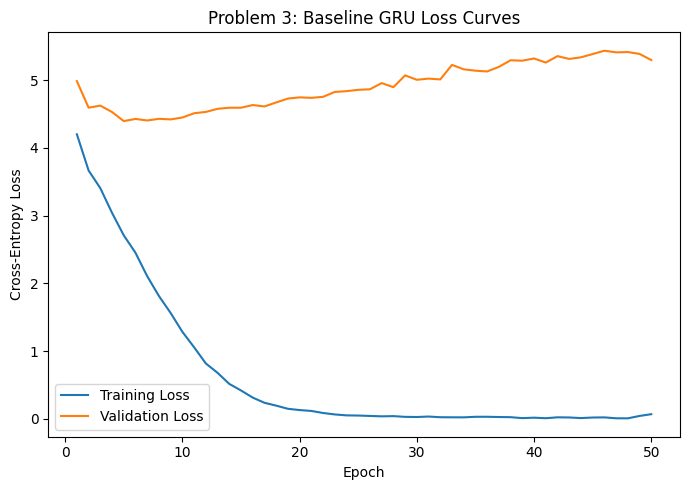

Saved to problem3_baseline_gru_loss_curve.png

=== Baseline GRU: Final Validation Metrics (Fr->Eng) ===
Exact-Match Accuracy: 0.00% | BLEU-4: 0.1180

FR: il enseigne la géographie mondiale à des classes de lycée
  Target: he teaches world geography to high school classes
  Predicted: he teaches to read classic science fiction novels
  Match: False | BLEU: 0.0650

FR: il joue de la basse dans un groupe de jazz professionnel
  Target: he plays bass guitar in a professional jazz band
  Predicted: he plays bass in a jazz band
  Match: False | BLEU: 0.1806

FR: les prévisions météo annoncent de fortes chutes de neige demain
  Target: the weather forecast predicts heavy snow tomorrow
  Predicted: the map is too hot to drink
  Match: False | BLEU: 0.0330

FR: elle adore porter de longues jupes amples en coton
  Target: she loves to wear long flowing cotton skirts
  Predicted: she wears an elegant for her lost dog
  Match: False | BLEU: 0.0278

FR: ils écoutent le professeur avec une attention

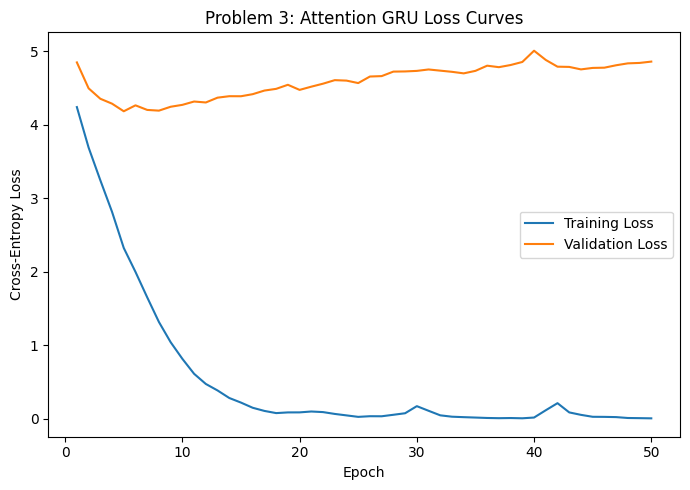

Saved to problem3_attention_gru_loss_curve.png

=== Attention GRU: Final Validation Metrics (Fr->Eng) ===
Exact-Match Accuracy: 0.00% | BLEU-4: 0.1433

FR: il enseigne la géographie mondiale à des classes de lycée
  Target: he teaches world geography to high school classes
  Predicted: he teaches molecular to advanced students
  Match: False | BLEU: 0.0685

FR: il joue de la basse dans un groupe de jazz professionnel
  Target: he plays bass guitar in a professional jazz band
  Predicted: he plays bass in a jazz band
  Match: False | BLEU: 0.1806

FR: les prévisions météo annoncent de fortes chutes de neige demain
  Target: the weather forecast predicts heavy snow tomorrow
  Predicted: the thick leaves are at 7 fashion
  Match: False | BLEU: 0.0330

FR: elle adore porter de longues jupes amples en coton
  Target: she loves to wear long flowing cotton skirts
  Predicted: she loves to wear long skirts
  Match: False | BLEU: 0.5698

FR: ils écoutent le professeur avec une attention absolue

In [ ]:
pairs3 = load_pairs(DATA_PATH, reverse=True)  # (french, english)
train_pairs3, val_pairs3 = split_pairs(pairs3, val_fraction=0.2, seed=RANDOM_SEED)
max_length3 = compute_max_length(pairs3)
print(f"Train: {len(train_pairs3)} | Val: {len(val_pairs3)} | MAX_LENGTH: {max_length3}")

src_vocab3, tgt_vocab3 = Vocabulary(), Vocabulary()  # src=French, tgt=English
for fr, eng in train_pairs3:
    src_vocab3.add_sentence(fr)
    tgt_vocab3.add_sentence(eng)
print(f"French vocab: {src_vocab3.n_words} | English vocab: {tgt_vocab3.n_words}")

train_loader3 = make_dataloader(train_pairs3, src_vocab3, tgt_vocab3, shuffle=True)
val_loader3 = make_dataloader(val_pairs3, src_vocab3, tgt_vocab3, shuffle=False)


def train_one_architecture(name, use_attention):
    """Trains either architecture on the reversed (Fr->Eng) data."""
    torch.manual_seed(RANDOM_SEED)
    encoder = EncoderRNN(src_vocab3.n_words, HIDDEN_SIZE).to(device)
    decoder = (AttnDecoderRNN(HIDDEN_SIZE, tgt_vocab3.n_words, max_length=max_length3, dropout_p = 0.3).to(device)
               if use_attention else DecoderRNN(HIDDEN_SIZE, tgt_vocab3.n_words, dropout_p = 0.3).to(device))
    enc_opt = torch.optim.Adam(encoder.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
    dec_opt = torch.optim.Adam(decoder.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

    tr_losses, va_losses = [], []
    for epoch in range(1, N_EPOCHS + 1):
        tr = run_epoch(train_loader3, encoder, decoder, criterion, use_attention, max_length3,
                        TEACHER_FORCING_RATIO, enc_opt, dec_opt, train=True)
        va = run_epoch(val_loader3, encoder, decoder, criterion, use_attention, max_length3,
                        teacher_forcing_ratio=1.0, train=False)
        tr_losses.append(tr); va_losses.append(va)
        if epoch % 5 == 0 or epoch == 1:
            print(f"[{name}] Epoch {epoch:3d}/{N_EPOCHS} | Train Loss: {tr:.4f} | Val Loss: {va:.4f}")

    tag = name.lower().replace(" ", "_")
    plot_loss_curves(tr_losses, va_losses, f"Problem 3: {name} Loss Curves", f"problem3_{tag}_loss_curve.png")

    results = evaluate_dataset(val_pairs3, src_vocab3, tgt_vocab3, encoder, decoder, use_attention,
                                max_length3, n_examples=N_QUALITATIVE_EXAMPLES, max_gen_length=MAX_GEN_LENGTH)
    results["final_val_loss"] = va_losses[-1]
    print(f"\n=== {name}: Final Validation Metrics (Fr->Eng) ===")
    print(f"Exact-Match Accuracy: {results['accuracy']*100:.2f}% | BLEU-4: {results['bleu']:.4f}\n")
    for src, tgt, pred, match, bleu in results["examples"]:
        print(f"FR: {src}\n  Target: {tgt}\n  Predicted: {pred}\n  Match: {match} | BLEU: {bleu:.4f}\n")
    return results, encoder, decoder


problem3_baseline_results, encoder3_base, decoder3_base = train_one_architecture("Baseline GRU", False)

problem3_attn_results, encoder3_attn, decoder3_attn = train_one_architecture("Attention GRU", True)



In [ ]:
# Final comparison
print(f"{'Model':<28}{'Direction':<14}{'Val Loss':<12}{'Exact Acc %':<14}{'BLEU-4':<10}")
print("-" * 78)
print(f"{'Problem 1: Baseline GRU':<28}{'Eng->Fr':<14}{problem1_results['final_val_loss']:<12.4f}"
      f"{problem1_results['accuracy']*100:<14.2f}{problem1_results['bleu']:<10.4f}")
print(f"{'Problem 2: Attention GRU':<28}{'Eng->Fr':<14}{problem2_results['final_val_loss']:<12.4f}"
      f"{problem2_results['accuracy']*100:<14.2f}{problem2_results['bleu']:<10.4f}")
print(f"{'Problem 3: Baseline GRU':<28}{'Fr->Eng':<14}{problem3_baseline_results['final_val_loss']:<12.4f}"
      f"{problem3_baseline_results['accuracy']*100:<14.2f}{problem3_baseline_results['bleu']:<10.4f}")
print(f"{'Problem 3: Attention GRU':<28}{'Fr->Eng':<14}{problem3_attn_results['final_val_loss']:<12.4f}"
      f"{problem3_attn_results['accuracy']*100:<14.2f}{problem3_attn_results['bleu']:<10.4f}")


Model                       Direction     Val Loss    Exact Acc %   BLEU-4    
------------------------------------------------------------------------------
Problem 1: Baseline GRU     Eng->Fr       5.6038      0.00          0.1126    
Problem 2: Attention GRU    Eng->Fr       5.1172      1.80          0.1352    
Problem 3: Baseline GRU     Fr->Eng       5.2955      0.00          0.1180    
Problem 3: Attention GRU    Fr->Eng       4.8582      0.00          0.1433    
